In [13]:
import os
import numpy as np
import SimpleITK as sitk
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
from scipy.ndimage import label, generate_binary_structure
import logging

sitk.ProcessObject.SetGlobalWarningDisplay(False)
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

def calculate_suv_peak(image_arr, mask_arr, spacing, radius_mm=6.2035):
    """Calcule le SUV Peak (sphère de ~1 mL autour du voxel le plus chaud du masque)."""
    masked_img = np.where(mask_arr > 0, image_arr, -np.inf)
    if np.all(masked_img == -np.inf): 
        return np.nan
        
    idx_z, idx_y, idx_x = np.unravel_index(np.argmax(masked_img), masked_img.shape)
    sp_x, sp_y, sp_z = spacing
    
    rad_z = int(np.ceil(radius_mm / sp_z))
    rad_y = int(np.ceil(radius_mm / sp_y))
    rad_x = int(np.ceil(radius_mm / sp_x))
    
    z_min = max(0, idx_z - rad_z)
    z_max = min(image_arr.shape[0], idx_z + rad_z + 1)
    y_min = max(0, idx_y - rad_y)
    y_max = min(image_arr.shape[1], idx_y + rad_y + 1)
    x_min = max(0, idx_x - rad_x)
    x_max = min(image_arr.shape[2], idx_x + rad_x + 1)
    
    box_arr = image_arr[z_min:z_max, y_min:y_max, x_min:x_max]
    zz, yy, xx = np.ogrid[z_min:z_max, y_min:y_max, x_min:x_max]
    
    dist2 = ((zz - idx_z) * sp_z)**2 + ((yy - idx_y) * sp_y)**2 + ((xx - idx_x) * sp_x)**2
    sphere_mask = dist2 <= (radius_mm**2)
    
    if not np.any(sphere_mask):
        return np.nan
    
    return np.mean(box_arr[sphere_mask])


def calculate_metrics(gt_arr, pred_arr, mask_arr, spacing):
    voxels_gt = gt_arr[mask_arr > 0]
    voxels_pred = pred_arr[mask_arr > 0]
    
    if len(voxels_gt) == 0:
        return None
        
    # --- aRE ---
    voxels_gt_safe = np.where(voxels_gt == 0, 1e-8, voxels_gt)
    are_val = np.mean(np.abs((voxels_pred - voxels_gt_safe) / voxels_gt_safe)) * 100
    
    # --- PSNR ---
    mse = np.mean((voxels_gt - voxels_pred) ** 2)
    max_val = np.max(voxels_gt)
    psnr_val = 10 * np.log10((max_val ** 2) / mse) if mse > 1e-8 else np.inf
    
    # --- COV (Coefficient of Variation) ---
    mean_gt, mean_pred = np.mean(voxels_gt), np.mean(voxels_pred)
    cov_gt = (np.std(voxels_gt) / mean_gt) if mean_gt > 1e-8 else 0
    cov_pred = (np.std(voxels_pred) / mean_pred) if mean_pred > 1e-8 else 0
    
    # --- Max ---
    max_gt, max_pred = np.max(voxels_gt), np.max(voxels_pred)
    
    # --- SUV Peak ---
    suv_peak_gt = calculate_suv_peak(gt_arr, mask_arr, spacing)
    suv_peak_pred = calculate_suv_peak(pred_arr, mask_arr, spacing)
    
    return {
        "aRE": are_val,
        "PSNR": psnr_val,
        "COV_GT": cov_gt,
        "COV_Pred": cov_pred,
        "Mean_GT": mean_gt,
        "Mean_Pred": mean_pred,
        "Max_GT": max_gt,
        "Max_Pred": max_pred,
        "SUV_Peak_GT": suv_peak_gt,
        "SUV_Peak_Pred": suv_peak_pred
    }


def process_single_subject(args):
    domain, subject_id, subject_path, gt_filenames, pseudo_filenames, gauss_filenames, std_filename, mask_filename, target_vois = args
    
    subject_results = {}
    
    # Liste des dossiers de VOIs physiquement présents pour ce patient
    available_vois = [f for f in os.listdir(subject_path) if os.path.isdir(os.path.join(subject_path, f))]
    
    # Nettoyage au cas où les VOIs en entrée contiendraient ".nii.gz"
    target_vois_clean = [v.replace('.nii.gz', '').replace('.nii', '') for v in target_vois]
    
    for std_key, gt_file in gt_filenames.items():
        std_results = {}
        
        methods_to_eval = {
            'PseudoEARL-Net': pseudo_filenames.get(std_key),
            'Gaussian-EARL': gauss_filenames.get(std_key),
            'Standard': std_filename
        }
        
        for voi_target in target_vois_clean:
            voi_folder = next((v for v in available_vois if v.lower() == voi_target.lower()), None)
            if not voi_folder:
                continue
                
            voi_path = os.path.join(subject_path, voi_folder)
            
            gt_path = os.path.join(voi_path, gt_file)
            mask_path = os.path.join(voi_path, mask_filename)
            
            if not os.path.exists(gt_path) or not os.path.exists(mask_path):
                continue
                
            try:
                gt_img = sitk.ReadImage(gt_path)
                gt_arr = sitk.GetArrayFromImage(gt_img)
                mask_img = sitk.ReadImage(mask_path)
                mask_arr = sitk.GetArrayFromImage(mask_img)
                spacing = gt_img.GetSpacing()
                
                is_lesion = voi_target.lower() in ['lesion', 'lesions']
                voi_metrics = {}
                
                # ==========================================
                # TRAITEMENT LÉSION : Multi-Composantes
                # ==========================================
                if is_lesion:
                    struct_3d = generate_binary_structure(3, 3)
                    labeled_arr, num_features = label(mask_arr > 0, structure=struct_3d)
                    
                    unique_labels, counts = np.unique(labeled_arr, return_counts=True)
                    size_dict = dict(zip(unique_labels, counts))
                    
                    for comp_idx in range(1, num_features + 1):
                        # Filtrage du bruit (< 10 voxels)
                        if size_dict.get(comp_idx, 0) < 10:
                            continue
                            
                        comp_mask = (labeled_arr == comp_idx).astype(np.uint8)
                        comp_metrics = {}
                        
                        for method_name, pred_file in methods_to_eval.items():
                            if not pred_file: continue
                            pred_path = os.path.join(voi_path, pred_file)
                            if not os.path.exists(pred_path): continue
                            
                            pred_arr = sitk.GetArrayFromImage(sitk.ReadImage(pred_path))
                            metrics = calculate_metrics(gt_arr, pred_arr, comp_mask, spacing)
                            
                            if metrics:
                                comp_metrics[method_name] = metrics
                                
                        if comp_metrics:
                            voi_metrics[comp_idx] = comp_metrics
                            
                # ==========================================
                # TRAITEMENT CLASSIQUE : Masque Global
                # ==========================================
                else:
                    for method_name, pred_file in methods_to_eval.items():
                        if not pred_file: continue
                        pred_path = os.path.join(voi_path, pred_file)
                        if not os.path.exists(pred_path): continue
                        
                        pred_arr = sitk.GetArrayFromImage(sitk.ReadImage(pred_path))
                        metrics = calculate_metrics(gt_arr, pred_arr, mask_arr, spacing)
                        
                        if metrics:
                            voi_metrics[method_name] = metrics
                            
                if voi_metrics:
                    std_results[voi_target] = voi_metrics
                    
            except Exception as e:
                pass # Silencieux pour ne pas crasher le multiprocessing
        
        if std_results:
            subject_results[std_key] = std_results
            
    return domain, subject_id, subject_results


# ==============================================================================
# FONCTION PRINCIPALE D'EXTRACTION
# ==============================================================================
def extract_comprehensive_metrics(
    base_dirs, # ex: ['data/PET-EARL/domain_a100', 'data/PET-EARL/domain_chb']
    gt_filenames={'earl1': 'earl1.nii.gz', 'earl2': 'earl2.nii.gz'},
    pseudo_filenames={'earl1': 'pseudo-earl1.nii.gz', 'earl2': 'pseudo-earl2.nii.gz'},
    gauss_filenames={'earl1': 'gaussian-earl1.nii.gz', 'earl2': 'gaussian-earl2.nii.gz'},
    std_filename='pet.nii.gz',
    mask_filename='mask.nii.gz', 
    target_vois=['liver', 'lung', 'brain', 'spleen', 'urinary_bladder', 'lesion'],
    num_workers=32
):
    if isinstance(base_dirs, str):
        base_dirs = [base_dirs]
        
    tasks = []
    for domain_dir in base_dirs:
        if not os.path.exists(domain_dir):
            logging.warning(f"Le dossier domaine {domain_dir} n'existe pas.")
            continue
            
        domain_name = os.path.basename(domain_dir)
        subjects = [s for s in os.listdir(domain_dir) if os.path.isdir(os.path.join(domain_dir, s))]
        
        for subj in subjects:
            subject_path = os.path.join(domain_dir, subj)
            tasks.append((
                domain_name, subj, subject_path,
                gt_filenames, pseudo_filenames, gauss_filenames,
                std_filename, mask_filename, target_vois
            ))
            
    master_dict = {}
    print(f"\n🚀 Lancement de l'extraction sur {len(tasks)} patients.")
    
    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        futures = {executor.submit(process_single_subject, task): task for task in tasks}
        
        for future in tqdm(as_completed(futures), total=len(tasks), desc="Extraction des Métriques"):
            domain, subject_id, subj_results = future.result()
            
            if subj_results:
                if domain not in master_dict:
                    master_dict[domain] = {}
                master_dict[domain][subject_id] = subj_results

    print("✅ Extraction terminée.")
    return master_dict


final_dict = extract_comprehensive_metrics(
    base_dirs=[
        '../outputs/pseudo-earl/a100',
        '../outputs/pseudo-earl/chb',
        '../outputs/pseudo-earl/rennes',
        '../outputs/pseudo-earl/nantes'
    ],
    mask_filename='mask.nii.gz', # Modifie si ton masque s'appelle différemment
    target_vois=['liver', 'lung', 'brain', 'spleen', 'urinary_bladder', 'lesion']
)


🚀 Lancement de l'extraction sur 313 patients.


Extraction des Métriques: 100%|██████████| 313/313 [02:50<00:00,  1.84it/s]

✅ Extraction terminée.


In [58]:
import pandas as pd
import numpy as np

def generate_are_psnr_table(master_dict):
    records = []
    
    # Définition stricte des centres par Standard
    valid_domains = {
        'earl2': ['nantes', 'domain_nantes'],
        # 'earl1': ['rennes', 'chb', 'a100', 'domain_rennes', 'domain_chb', 'domain_a100'],
        # 'earl2': ['nantes', 'a100', 'domain_nantes', 'domain_a100']
    }
    
    # 1. Aplatissement du dictionnaire
    for domain, subjects in master_dict.items():
        domain_clean = domain.lower()
        
        for subj, std_data in subjects.items():
            for std_key, voi_data in std_data.items(): # std_key = 'earl1' ou 'earl2'
                
                # Filtrage strict du centre selon le standard cible
                if domain_clean not in valid_domains.get(std_key, []):
                    continue
                    
                target_label = std_key.upper()
                
                for voi, methods_data in voi_data.items():
                    # --- Gestion des Lésions (Multi-Composantes) ---
                    if voi.lower() in ['lesion', 'lesions']:
                        display_voi = 'Lesions'
                        # methods_data est de type {comp_idx: {method: metrics}}
                        for comp_idx, comp_methods in methods_data.items():
                            for method, metrics in comp_methods.items():
                                if method == 'Standard': continue
                                
                                # Nom de méthode formatté comme sur l'image
                                display_method = f"Gaussian-{target_label}" if "Gaussian" in method else "PseudoEARL-Net"
                                
                                records.append({
                                    'Target': target_label,
                                    'Method': display_method,
                                    'VOI': display_voi,
                                    'aRE': metrics['aRE'],
                                    'PSNR': metrics['PSNR']
                                })
                                
                    # --- Gestion des autres Organes (Global) ---
                    else:
                        display_voi = 'Bladder' if 'bladder' in voi.lower() else voi.capitalize()
                        
                        for method, metrics in methods_data.items():
                            if method == 'Standard': continue
                            
                            display_method = f"Gaussian-{target_label}" if "Gaussian" in method else "PseudoEARL-Net"
                            
                            records.append({
                                'Target': target_label,
                                'Method': display_method,
                                'VOI': display_voi,
                                'aRE': metrics['aRE'],
                                'PSNR': metrics['PSNR']
                            })
                            
    # 2. Création du DataFrame et Moyenne
    df_flat = pd.DataFrame(records)
    
    if df_flat.empty:
        print("⚠️ Aucune donnée ne correspond aux critères de filtrage.")
        return None
        
    df_agg = df_flat.groupby(['Target', 'Method', 'VOI']).mean().reset_index()
    
    # 3. Pivot pour correspondre à l'image (Tableau croisé)
    table = df_agg.pivot(index=['Target', 'Method'], columns='VOI', values=['aRE', 'PSNR'])
    
    # 4. Esthétique : Réorganisation des colonnes et des index
    table = table.swaplevel(axis=1) # Inverse l'ordre (VOI au dessus de la métrique)
    
    # Ordre spécifique des VOIs et métriques
    ordered_vois = ['Brain', 'Liver', 'Lung', 'Spleen', 'Bladder', 'Lesions']
    ordered_metrics = ['aRE', 'PSNR']
    
    # Filtre les VOIs qui sont réellement présentes dans les données pour éviter les KeyError
    existing_vois = [v for v in ordered_vois if v in table.columns.levels[0]]
    
    table = table.reindex(columns=pd.MultiIndex.from_product([existing_vois, ordered_metrics]))
    
    # Ordre spécifique des lignes
    ordered_methods = [
        # ('EARL1', 'Gaussian-EARL1'), ('EARL1', 'PseudoEARL-Net'),
        ('EARL2', 'Gaussian-EARL2'), ('EARL2', 'PseudoEARL-Net')
    ]
    existing_methods = [m for m in ordered_methods if m in table.index]
    table = table.reindex(existing_methods)
    
    return table

# =========================================================
# EXÉCUTION
# =========================================================
# (On suppose que final_dict est le résultat retourné par ta fonction d'extraction)

summary_table = generate_are_psnr_table(final_dict)
summary_table

Brain       Liver       Lung       Spleen       Bladder  \
                        aRE  PSNR   aRE  PSNR  aRE  PSNR    aRE  PSNR     aRE   
Target Method                                                                   
EARL2  Gaussian-EARL2  9.61 26.45  4.51 31.48 7.15 34.15   4.86 29.88   27.02   
       PseudoEARL-Net  0.27 53.90  0.26 53.75 0.43 56.82   0.27 52.84    0.46   

                            Lesions        
                       PSNR     aRE  PSNR  
Target Method                              
EARL2  Gaussian-EARL2 25.13   22.79 15.67  
       PseudoEARL-Net 56.30    0.42 48.95

In [56]:
import pandas as pd
import numpy as np

def generate_delta_suv_table(
    master_dict,
    target_domains=None,
    target_vois=None,
    target_methods=None
):
    """
    Génère un tableau des erreurs de quantification ΔSUV (Max, Mean, Peak).
    
    Paramètres:
    - master_dict : Le dictionnaire extrait (contenant tous les patients).
    - target_domains : Liste des domaines à inclure (ex: ['chb', 'rennes']). Par défaut: Tous.
    - target_vois : Liste des VOIs à inclure. Par défaut: Les 6 classiques.
    - target_methods : Liste des méthodes à inclure. Par défaut: Pseudo et Gaussien.
    """
    
    # 1. Initialisation et configuration des filtres par défaut
    if target_vois is None:
        target_vois = ['Liver', 'Brain', 'Lung', 'Bladder', 'Spleen', 'Lesion']
    if target_methods is None:
        target_methods = ['PseudoEARL-Net', 'Gaussian-EARL']
        
    # Normalisation des domaines fournis par l'utilisateur (ex: 'domain_chb' -> 'chb')
    if target_domains is not None:
        target_domains_clean = [d.lower().replace('domain_', '') for d in target_domains]
    else:
        target_domains_clean = None

    records = []
    
    # 2. Aplatissement du dictionnaire avec application des filtres
    for domain, subjects in master_dict.items():
        domain_clean = domain.lower().replace('domain_', '')
        
        # --- Filtre par domaine ---
        if target_domains_clean is not None and domain_clean not in target_domains_clean:
            continue
            
        for subj, std_data in subjects.items():
            for std_key, voi_data in std_data.items():
                
                for voi, methods_data in voi_data.items():
                    # Normalisation du nom de la VOI
                    if voi.lower() in ['lesion', 'lesions']:
                        display_voi = 'Lesion'
                    elif 'bladder' in voi.lower():
                        display_voi = 'Bladder'
                    else:
                        display_voi = voi.capitalize()
                        
                    # --- Filtre par VOI ---
                    if display_voi not in target_vois:
                        continue
                        
                    # --- Gestion des Lésions (Multi-Composantes) ---
                    if display_voi == 'Lesion':
                        for comp_idx, comp_methods in methods_data.items():
                            for method, metrics in comp_methods.items():
                                if method == 'Standard': continue
                                
                                display_method = "Gaussian-EARL" if "Gaussian" in method else "PseudoEARL-Net"
                                
                                # --- Filtre par méthode ---
                                if display_method not in target_methods:
                                    continue
                                    
                                records.append({
                                    'Domain': domain_clean,
                                    'VOI': display_voi,
                                    'Method': display_method,
                                    'Max_GT': metrics.get('Max_GT', np.nan),
                                    'Max_Pred': metrics.get('Max_Pred', np.nan),
                                    'Mean_GT': metrics.get('Mean_GT', np.nan),
                                    'Mean_Pred': metrics.get('Mean_Pred', np.nan),
                                    'Peak_GT': metrics.get('SUV_Peak_GT', np.nan),
                                    'Peak_Pred': metrics.get('SUV_Peak_Pred', np.nan)
                                })
                                
                    # --- Gestion des autres Organes (Global) ---
                    else:
                        for method, metrics in methods_data.items():
                            if method == 'Standard': continue
                            
                            display_method = "Gaussian-EARL" if "Gaussian" in method else "PseudoEARL-Net"
                            
                            # --- Filtre par méthode ---
                            if display_method not in target_methods:
                                continue
                                
                            records.append({
                                'Domain': domain_clean,
                                'VOI': display_voi,
                                'Method': display_method,
                                'Max_GT': metrics.get('Max_GT', np.nan),
                                'Max_Pred': metrics.get('Max_Pred', np.nan),
                                'Mean_GT': metrics.get('Mean_GT', np.nan),
                                'Mean_Pred': metrics.get('Mean_Pred', np.nan),
                                'Peak_GT': metrics.get('SUV_Peak_GT', np.nan),
                                'Peak_Pred': metrics.get('SUV_Peak_Pred', np.nan)
                            })
                            
    df_flat = pd.DataFrame(records)
    
    if df_flat.empty:
        print("⚠️ Aucune donnée n'a pu être extraite avec ces filtres.")
        return None

    # 3. Calcul des Deltas pour chaque métrique
    for m in ['Max', 'Mean', 'Peak']:
        df_flat[f'Raw_Delta_{m}'] = np.abs(df_flat[f'{m}_Pred'] - df_flat[f'{m}_GT'])
        df_flat[f'Rel_Delta_{m}'] = np.where(
            df_flat[f'{m}_GT'] != 0,
            (df_flat[f'Raw_Delta_{m}'] / df_flat[f'{m}_GT']) * 100,
            np.nan
        )

    # 4. Définition de l'ordre d'affichage final (basé sur les requêtes)
    default_vois_order = ['Liver', 'Brain', 'Lung', 'Bladder', 'Spleen', 'Lesion']
    ordered_vois = [v for v in default_vois_order if v in target_vois]
    # Ajout des VOIs exotiques éventuelles à la fin
    for v in target_vois:
        if v not in ordered_vois:
            ordered_vois.append(v)

    default_methods_order = ['PseudoEARL-Net', 'Gaussian-EARL']
    ordered_methods = [m for m in default_methods_order if m in target_methods]
    
    ordered_metrics = ['Max', 'Mean', 'Peak']
    
    table_rows = []
    
    # 5. Agrégation et Formatage
    for voi in ordered_vois:
        row_data = {('VOI', ''): voi}
        
        for method in ordered_methods:
            df_subset = df_flat[(df_flat['VOI'] == voi) & (df_flat['Method'] == method)]
            
            for m in ordered_metrics:
                raw_vals = df_subset[f'Raw_Delta_{m}'].dropna()
                rel_vals = df_subset[f'Rel_Delta_{m}'].dropna()
                
                if len(raw_vals) > 0:
                    raw_mean = raw_vals.mean()
                    raw_std = raw_vals.std(ddof=1) if len(raw_vals) > 1 else 0.0
                    rel_mean = rel_vals.mean()
                    
                    # Format exact: -0.01 ± 0.08 (-0.22%)
                    formatted_str = f"{raw_mean:+.2f} ± {raw_std:.2f} ({rel_mean:+.2f}%)"
                else:
                    formatted_str = "N/A"
                    
                col_key = (method, f"SUV_{m.lower()}")
                row_data[col_key] = formatted_str
                
        table_rows.append(row_data)

    # 6. Création du DataFrame multi-indexé
    multi_columns = pd.MultiIndex.from_tuples(
        [('VOI', '')] + 
        [(method, f"SUV_{m.lower()}") for method in ordered_methods for m in ordered_metrics]
    )
    
    final_df = pd.DataFrame(
        [[row.get(col, '') for col in multi_columns] for row in table_rows],
        columns=multi_columns
    )
    
    final_df = final_df.set_index(('VOI', ''))
    final_df.index.name = None 
    
    return final_df

# =========================================================
# EXEMPLES D'EXÉCUTION
# =========================================================

table_globale = generate_delta_suv_table(final_dict)
table_globale

PseudoEARL-Net                                                \
                       SUV_max               SUV_mean               SUV_peak   
Liver    +0.04 ± 0.07 (+0.78%)  +0.00 ± 0.00 (+0.05%)  +0.03 ± 0.07 (+0.80%)   
Brain    +0.09 ± 0.33 (+0.66%)  +0.00 ± 0.02 (+0.05%)  +0.12 ± 0.26 (+1.07%)   
Lung     +0.03 ± 0.05 (+0.75%)  +0.00 ± 0.00 (+0.09%)  +0.02 ± 0.06 (+0.77%)   
Bladder  +0.44 ± 1.19 (+0.59%)  +0.02 ± 0.04 (+0.14%)  +0.38 ± 0.74 (+0.76%)   
Spleen   +0.03 ± 0.09 (+0.77%)  +0.00 ± 0.00 (+0.08%)  +0.02 ± 0.05 (+0.78%)   
Lesion   +0.08 ± 0.23 (+1.21%)  +0.03 ± 0.05 (+0.70%)  +0.05 ± 0.10 (+0.94%)   

                   Gaussian-EARL                          \
                         SUV_max                SUV_mean   
Liver     +0.60 ± 0.60 (+10.95%)   +0.02 ± 0.01 (+0.84%)   
Brain     +1.52 ± 1.11 (+11.28%)   +0.11 ± 0.07 (+1.69%)   
Lung      +0.43 ± 0.61 (+11.31%)   +0.01 ± 0.01 (+1.86%)   
Bladder  +9.10 ± 16.48 (+12.00%)   +0.67 ± 0.75 (+4.01%)   
Spleen    +0.57 ± 1.88 (+10.43%)   +0.03 ± 0.02 (+1.50%)   
Lesion    +1.63 ± 2.00 (+24.05%)  +0.67 ± 0.59 (+16.47%)   

                                 
                       SUV_peak  
Liver     +0.30 ± 0.34 (+6.98%)  
Brain     +0.49 ± 0.44 (+4.39%)  
Lung      +0.20 ± 0.32 (+5.81%)  
Bladder   +5.01 ± 9.60 (+7.90%)  
Spleen    +0.25 ± 0.81 (+5.15%)  
Lesion   +0.68 ± 0.75 (+14.56%)

In [59]:
table_filtree = generate_delta_suv_table(
    final_dict,
    target_domains=['nantes']
)
table_filtree

PseudoEARL-Net                                                \
                       SUV_max               SUV_mean               SUV_peak   
Liver    +0.02 ± 0.02 (+0.29%)  +0.00 ± 0.00 (+0.04%)  +0.01 ± 0.01 (+0.23%)   
Brain    +0.04 ± 0.05 (+0.29%)  +0.00 ± 0.00 (+0.01%)  +0.06 ± 0.16 (+0.51%)   
Lung     +0.01 ± 0.01 (+0.26%)  +0.00 ± 0.00 (+0.07%)  +0.01 ± 0.04 (+0.43%)   
Bladder  +0.39 ± 1.44 (+0.33%)  +0.01 ± 0.01 (+0.06%)  +0.29 ± 0.65 (+0.43%)   
Spleen   +0.01 ± 0.04 (+0.32%)  +0.00 ± 0.00 (+0.05%)  +0.01 ± 0.03 (+0.31%)   
Lesion   +0.03 ± 0.06 (+0.39%)  +0.01 ± 0.03 (+0.22%)  +0.02 ± 0.06 (+0.35%)   

                    Gaussian-EARL                          \
                          SUV_max                SUV_mean   
Liver      +0.74 ± 0.77 (+13.29%)   +0.02 ± 0.01 (+1.06%)   
Brain      +2.00 ± 0.74 (+14.16%)   +0.13 ± 0.05 (+2.02%)   
Lung       +0.55 ± 0.77 (+14.45%)   +0.02 ± 0.00 (+2.65%)   
Bladder  +16.13 ± 26.95 (+17.92%)   +0.69 ± 0.57 (+4.69%)   
Spleen     +0.80 ± 3.34 (+11.40%)   +0.04 ± 0.02 (+1.86%)   
Lesion     +2.68 ± 3.38 (+32.79%)  +1.10 ± 0.79 (+23.46%)   

                                  
                        SUV_peak  
Liver      +0.38 ± 0.37 (+8.83%)  
Brain      +0.61 ± 0.53 (+4.94%)  
Lung       +0.25 ± 0.38 (+7.95%)  
Bladder  +8.38 ± 16.20 (+11.47%)  
Spleen     +0.32 ± 1.35 (+5.29%)  
Lesion    +1.01 ± 1.11 (+19.47%)

📊 Génération du double scatter plot pour 346 lésions (Domaine CHB)...


/tmp/ipykernel_3712754/3094653825.py:82: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(f"suvmax_scatter_dual_standard_lesions_{target_domain}.svg", format='svg', dpi=300, bbox_inches='tight')
/tmp/ipykernel_3712754/3094653825.py:82: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(f"suvmax_scatter_dual_standard_lesions_{target_domain}.svg", format='svg', dpi=300, bbox_inches='tight')
/tmp/ipykernel_3712754/3094653825.py:82: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(f"suvmax_scatter_dual_standard_lesions_{target_domain}.svg", format='svg', dpi=300, bbox_inches='tight')

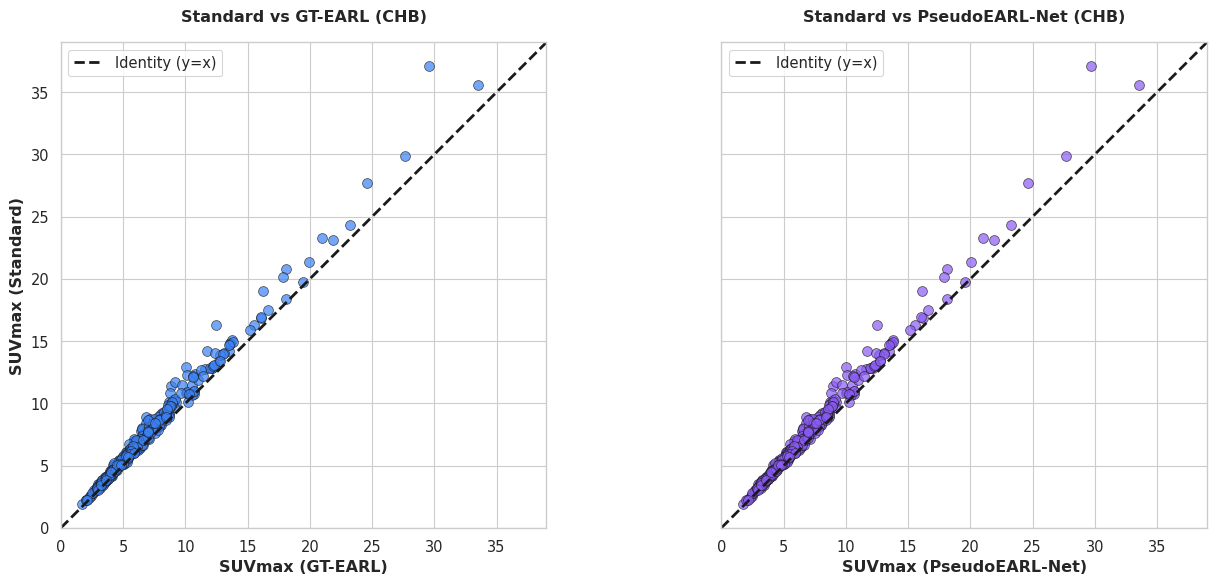

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_lesion_suvmax_scatter_dual_standard(master_dict, target_domain='chb'):
    records = []
    
    # 1. Extraction ciblée (Standard + Pseudo + GT)
    for domain, subjects in master_dict.items():
        if target_domain and target_domain not in domain.lower():
            continue
            
        for subj, std_data in subjects.items():
            for std_key, voi_data in std_data.items():
                for voi, methods_data in voi_data.items():
                    if voi.lower() in ['lesion', 'lesions']:
                        
                        # Itération sur chaque foyer
                        for comp_idx, comp_methods in methods_data.items():
                            
                            # On a besoin à la fois du Standard et du PseudoEARL-Net
                            if 'Standard' in comp_methods and 'PseudoEARL-Net' in comp_methods:
                                std_metrics = comp_methods['Standard']
                                pseudo_metrics = comp_methods['PseudoEARL-Net']
                                
                                # Le GT est identique pour tout le monde dans ce foyer
                                gt_val = std_metrics.get('Max_GT') 
                                std_val = std_metrics.get('Max_Pred')
                                pseudo_val = pseudo_metrics.get('Max_Pred')
                                
                                if gt_val is not None and std_val is not None and pseudo_val is not None:
                                    records.append({
                                        'SUVmax_GT': gt_val,
                                        'SUVmax_Standard': std_val,
                                        'SUVmax_Pseudo': pseudo_val
                                    })
                                    
    df = pd.DataFrame(records)
    
    if df.empty:
        print(f"❌ Aucune donnée lésionnelle complète trouvée pour le domaine {target_domain.upper()}.")
        return
        
    print(f"📊 Génération du double scatter plot pour {len(df)} lésions (Domaine {target_domain.upper()})...")
    
    # 2. Configuration de la figure (1 ligne, 2 colonnes)
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, sharex=True)
    
    # Calcul de la limite maximale globale pour avoir un graphe parfaitement carré
    max_limit = max(df['SUVmax_GT'].max(), df['SUVmax_Standard'].max(), df['SUVmax_Pseudo'].max()) * 1.05
    
    # --- Sous-graphique 1 : Standard vs GT-EARL (Gauche) ---
    sns.scatterplot(
        data=df, x='SUVmax_GT', y='SUVmax_Standard', 
        ax=axes[0], color='#3b82f6', alpha=0.7, edgecolor='k', s=50 
    )
    axes[0].plot([0, max_limit], [0, max_limit], 'k--', lw=2, label='Identity (y=x)')
    axes[0].set_title(f'Standard vs GT-EARL ({target_domain.upper()})', fontweight='bold', pad=15)
    axes[0].set_xlabel('SUVmax (GT-EARL)', fontweight='bold')
    axes[0].set_ylabel('SUVmax (Standard)', fontweight='bold')
    axes[0].legend()
    
    # --- Sous-graphique 2 : Standard vs PseudoEARL-Net (Droite) ---
    sns.scatterplot(
        data=df, x='SUVmax_Pseudo', y='SUVmax_Standard', 
        ax=axes[1], color='#8b5cf6', alpha=0.7, edgecolor='k', s=50 
    )
    axes[1].plot([0, max_limit], [0, max_limit], 'k--', lw=2, label='Identity (y=x)')
    axes[1].set_title(f'Standard vs PseudoEARL-Net ({target_domain.upper()})', fontweight='bold', pad=15)
    axes[1].set_xlabel('SUVmax (PseudoEARL-Net)', fontweight='bold')
    axes[1].legend()
    
    # Ajustements esthétiques finaux
    for ax in axes:
        ax.set_xlim(0, max_limit)
        ax.set_ylim(0, max_limit)
        ax.set_aspect('equal', adjustable='box')
        
    plt.tight_layout()
    plt.savefig(f"suvmax_scatter_dual_standard_lesions_{target_domain}.svg", format='svg', dpi=300, bbox_inches='tight')
    plt.show()

# =========================================================
# EXÉCUTION
# =========================================================
plot_lesion_suvmax_scatter_dual_standard(final_dict, target_domain='chb')